# Arabic Dialect Classification

This notebook is the presentation artifact for the project. It explains the dataset, baseline, final model, experiments, error analysis, and FastAPI deployment.

The production code is in:

- `src/preprocess.py`
- `src/regex_baseline.py`
- `src/train.py`
- `app/main.py`
- `app/schemas.py`

The notebook is not the production pipeline. It documents the reasoning and results.

![Arabic dialect clustering](/Users/denizasuleymanova/projects/arabic-dialect-classification/resources/Arabic-Dialect-Group-Map-1024x496.jpg)

## 1. Project goal

The task is to classify short Arabic text snippets into one of five dialect labels:

| Label | Meaning |
|---|---|
| `EGY` | Egyptian Arabic |
| `GLF` | Gulf Arabic |
| `LAV` | Levantine Arabic |
| `NOR` | North African Arabic |
| `MSA` | Modern Standard Arabic |

This is useful because dialect identification can route user text to the correct downstream NLP pipeline, for example localization, search, support, moderation, or dialect-aware analytics. It's also useful for language learners, as oftentimes when learning a language one can get confused by dialects. Typically Arabic learners picka dialect to learn alongside MSA, thus when one finds snippets of text out in the wild (songs, blog posts, Tweets), its important to classify them properly for educational purposes.

In [96]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

PROJECT_ROOT = None
for root in candidate_roots:
    if (root / "data" / "processed" / "train.csv").exists() and (
        root / "models" / "arabic_dialect_model.joblib"
    ).exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find project root. Make sure preprocessing/training have already created "
        "data/processed/*.csv and models/arabic_dialect_model.joblib."
    )

train_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "train.csv")
val_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "val.csv")
test_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "test.csv")
model = joblib.load(PROJECT_ROOT / "models" / "arabic_dialect_model.joblib")

print("Project root:", PROJECT_ROOT)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
display(train_df.head())

Project root: /Users/denizasuleymanova/projects/arabic-dialect-classification
Train: (7983, 2)
Validation: (1008, 2)
Test: (1013, 2)


,text,label
0,ههههههههههههههههههههههههههههههههههههههههههه ياافنديه مصر دي ام الدنيا وشعبها احسن ناس وشعب متقدم جدااااااا الي انتم بتعملوه اليوم احنا ع...,EGY
1,اه جند رقص روتينيه هي يعني عندها صيت عالمي ومشروع كيف تعرف القسطنطينيه مشاهدي قناه ديكسفيل جزايريا,NOR
2,لمنطقه ايريز ما بقي في التعليل بالشيخ حتي ما يخدمها,NOR
3,ولا اتحدث بعد المشاكل منطقتنا تحب تبعد المجاهد,NOR
4,اذا كانت فعقد عاجز علي ان يقوم بواجبه في اكثر من مغبه منها التقطير والتكوين والتقييم والامتحانات والبرامج كل هذا الي ان بقطاعنا انساني ا...,NOR


## 1.5 Preprocessing decisions

The project uses light Arabic normalization. The goal is to remove technical noise while preserving dialectal spelling patterns.

The preprocessing removes URLs, usernames, diacritics, and repeated whitespace. It also normalizes some Arabic letter variants, such as Alef forms.

This can affect dialect classification because spelling variation is part of the signal. For example, normalizing `ة` to `ه` may reduce noise in informal text, but it can also remove a formal-vs-informal writing distinction. For this reason, the preprocessing is intentionally light. A future ablation study could compare the model with and without each normalization step.

| Step | Why it helps | Possible risk |
|---|---|---|
| Remove URLs/usernames | Removes platform noise | Usually low risk |
| Remove diacritics | Most informal Arabic lacks diacritics | Could remove formal/MSA signal |
| Normalize Alef forms | Reduces spelling inconsistency | May remove orthographic formality |
| Normalize `ة` to `ه` | Captures informal spelling | May weaken MSA vs dialect distinction |

## 2. Dataset overview

The dataset comes from Hugging Face: `drelhaj/Arabic-Dialects`, configuration `full_text`.

The project normalizes the original columns into:

| Project column | Meaning |
|---|---|
| `text` | Arabic text snippet |
| `label` | Dialect class |

The class distribution matters because the dataset is imbalanced. This is why macro-F1 is the main metric.

In [97]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
    }
)
split_summary

,split,rows
0,train,7983
1,validation,1008
2,test,1013


In [98]:
label_counts = (
    train_df["label"].value_counts().rename_axis("label").reset_index(name="count")
)
label_counts["percentage"] = (
    label_counts["count"] / label_counts["count"].sum() * 100
).round(2)
label_counts

,label,count,percentage
0,EGY,3152,39.48
1,LAV,1406,17.61
2,GLF,1337,16.75
3,NOR,1289,16.15
4,MSA,799,10.01


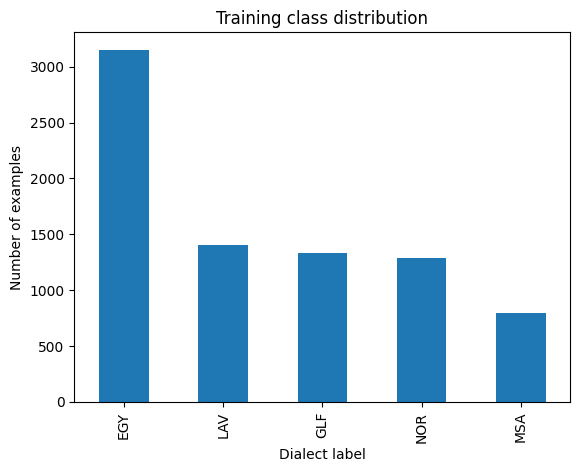

In [99]:
ax = label_counts.set_index("label")["count"].plot(
    kind="bar", title="Training class distribution"
)
ax.set_xlabel("Dialect label")
ax.set_ylabel("Number of examples")
plt.show()

## 3. Text examples

Looking at examples helps verify that the problem is realistic and that the labels correspond to short Arabic text snippets.

In [100]:
for label in sorted(train_df["label"].unique()):
    print("\n" + "=" * 80)
    print(label)
    display(train_df[train_df["label"] == label][["text", "label"]].head(3))


EGY


,text,label
0,ههههههههههههههههههههههههههههههههههههههههههه ياافنديه مصر دي ام الدنيا وشعبها احسن ناس وشعب متقدم جدااااااا الي انتم بتعملوه اليوم احنا ع...,EGY
8,هو سعر حديد عز بكام انهارده يا معلم جمال؟,EGY
10,هل واحد مثل هذا الشخص كان يمكن له ان يجد لهو دور في النادي الاهلي ( نادي القرن ) ولذلك احمد الله تعالي علي ان نادي القرن لم يتذكره في ال...,EGY



GLF


,text,label
5,توفي اليوم عن صباح الخير يا رفيق,GLF
26,نويه تدري ما الرصاص الها خصومه من الجار 150 دولارا بدولار,GLF
30,بالتنسيق مع اللجان الشبابيه داخل مدارس مشاركين في اللجان شكل مناديب مرشحين علي اتصال بيننا وبينهم خلال كل ساعه وكل ساعات زودونا في ال ال...,GLF



LAV


,text,label
6,كسر حلقه لانه مدرس للحكومه اكيد اجي بكون او فارول الاساس فيها في نخبه كامل من موجدين في يعني طالعين متاهلين ومتدربين ملي للجامعات الحكوم...,LAV
7,جمهور المصاب للمطار,LAV
9,واذا الهولنديه في العماره يعني الجانب الثاني,LAV



MSA


,text,label
20,طيب التوتر اذا ما تصاعد علي الحدود في فترات تاريخيه سابقه لمصر رفع شعار لا صوت يعلو فوق صوت المعركه استغلالا للتوتر في العلاقات مع اسراي...,MSA
34,شكرا جزيلا لك,MSA
36,تعهد حزب المجاهدين الكشميري الموالي لباكستان بمواصله القتال ضد الجيش الهندي حتي يتم طرده من اقليم كشمير وقال السيد صلاح الدين القايد الا...,MSA



NOR


,text,label
1,اه جند رقص روتينيه هي يعني عندها صيت عالمي ومشروع كيف تعرف القسطنطينيه مشاهدي قناه ديكسفيل جزايريا,NOR
2,لمنطقه ايريز ما بقي في التعليل بالشيخ حتي ما يخدمها,NOR
3,ولا اتحدث بعد المشاكل منطقتنا تحب تبعد المجاهد,NOR


## 4. Text length analysis

Short texts are harder because there are fewer dialectal signals. Longer texts usually give the model more character and word patterns.

In [101]:
for df in [train_df, val_df, test_df]:
    df["text_length"] = df["text"].astype(str).str.len()

length_summary = train_df.groupby("label")["text_length"].describe()[
    ["mean", "50%", "min", "max"]
]
length_summary

,mean,50%,min,max
label,,,,
EGY,152.934645,89.0,5.0,2003.0
GLF,191.397906,100.0,1.0,3162.0
LAV,199.784495,112.0,1.0,1833.0
MSA,283.227785,206.0,6.0,2367.0
NOR,174.018619,115.0,2.0,2214.0


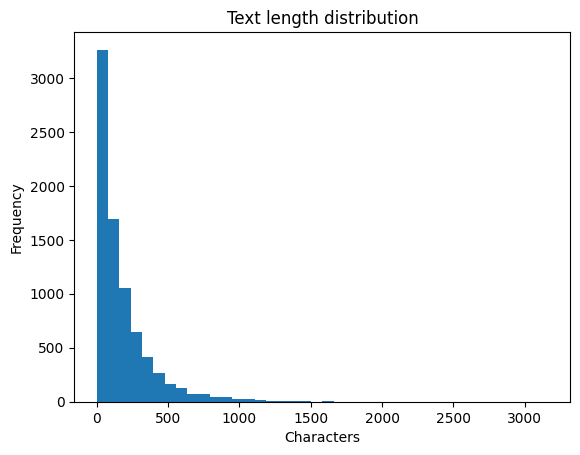

In [102]:
ax = train_df["text_length"].plot(
    kind="hist", bins=40, title="Text length distribution"
)
ax.set_xlabel("Characters")
plt.show()

## 5. Metric choice

The primary metric is **F1-macro**.

Accuracy is still reported, but it can be misleading with imbalanced classes. Macro-F1 gives equal weight to every dialect, so weak performance on smaller classes is not hidden by strong performance on the largest class.

## 6. Baseline: regex/rule classifier

The first baseline uses manually selected dialect marker words. If no marker is found, the classifier falls back to the majority class from the training set.

This baseline is intentionally simple. It gives a minimum comparison point and shows whether hand-written rules are enough.

In [103]:
DIALECT_MARKERS = {
    "EGY": [
        # Pronouns & demonstratives
        "احنا",
        "انتو",
        "هما",
        "ده",
        "دي",
        "دول",
        "دا",
        # Negation
        "مش",
        "مفيش",
        "ملقيش",
        "معنيش",
        # Common words
        "عايز",
        "عاوز",
        "اوي",
        "كده",
        "كدا",
        "زي",
        "بتاع",
        "بتاعي",
        "النهارده",
        "امبارح",
        "بكره",
        "دلوقتي",
        "هنا",
        "هناك",
        "ازاي",
        "ليه",
        "فين",
        "ايه",
        "امتى",
        # Verbs / expressions
        "بيعمل",
        "هيعمل",
        "بتعمل",
        "هتعمل",
        "عملت",
        "اتعمل",
        "يعني",
        "طب",
        "يلا",
        "ماشي",
        "تمام",
        "اهو",
        "خلاص",
        # Laughter / filler
        "هههه",
        "ههه",
    ],
    "GLF": [
        # Pronouns
        "انتو",
        "احنا",
        "هم",
        "انتي",
        # Demonstratives
        "هذا",
        "هذي",
        "هذول",
        "ذا",
        "چذا",
        # Common words
        "شلون",
        "اشلون",
        "وايد",
        "هلا",
        "ترى",
        "ابي",
        "ابغى",
        "وش",
        "ليش",
        "وينك",
        "عقب",
        "الحين",
        "ماكو",
        "اكو",
        "يبه",
        "يمه",
        "زين",
        "خوش",
        "مرة",
        "ثحين",
        "الثحين",
        "چان",
        "چانت",
        "يگول",
        "گال",  # Iraqi Gulf (kaf → g/ch)
        # Expressions
        "ان شاء الله",
        "الله يسلمك",
        "مستانس",
        "هلا والله",
        "بعد",
        "بس",
        "اهل",
        "اهلين",
        # Place markers that leak into text
        "الكويت",
        "الإمارات",
        "قطر",
        "الرياض",
        "جدة",
    ],
    "LAV": [
        # Pronouns
        "انا",
        "نحنا",
        "انتو",
        "هنه",
        "هني",
        # Demonstratives
        "هاد",
        "هاي",
        "هدول",
        # Common words
        "شو",
        "كتير",
        "هلق",
        "هلأ",
        "هيك",
        "بدي",
        "بدك",
        "بده",
        "ليش",
        "وينك",
        "نحنا",
        "ما في",
        "منيح",
        "عنجد",
        "رح",
        "رح يروح",
        "عم",
        "عم يعمل",  # progressive marker
        "لأنو",
        "كيفك",
        "كيفو",
        "تعا",
        "تعي",
        "يلا",
        "مش",
        "مو",
        "ما بدي",
        "ما رح",
        # Expressions
        "يي",
        "اه",
        "آه",
        "يعطيك العافية",
        "الله يعطيك",
        "سلامتك",
        "والله",
    ],
    "NOR": [
        # Pronouns
        "انا",
        "احنا",
        "نتا",
        "نتي",
        "هوما",
        # Common words
        "شنو",
        "اشنو",
        "واش",
        "بزاف",
        "برشا",
        "ديال",
        "ديالي",
        "ديالك",
        "راهو",
        "راني",
        "راك",
        "راه",
        "نحب",
        "باش",
        "علاش",
        "ماشي",
        "كيفاش",
        "فاش",
        "علاش",
        "بكري",
        "دابا",
        "دازت",
        "خويا",
        "صاحبي",
        "حبيبي",
        # Moroccan/Algerian specific
        "والو",
        "بلا",
        "بلاش",
        "زعما",
        "مزيان",
        "بيها",
        "كيران",
        "كاين",
        "كاينة",
        "مكاينش",
        # Loanwords from French/Berber common in NOR
        "كار",
        "طوموبيل",
    ],
    "MSA": [
        # Formal connectors
        "حيث",
        "وقد",
        "إذ",
        "بينما",
        "في حين",
        "على الرغم",
        "بسبب",
        "نتيجة",
        "وفقاً",
        "وفقا",
        "بحسب",
        "وفق",
        # Formal verbs / reporting
        "أعلنت",
        "أكد",
        "صرح",
        "أفاد",
        "أشار",
        "كشف",
        "أوضح",
        "قالت",
        "ذكر",
        "لفت",
        "نوه",
        "استعرض",
        # Institutions / formal nouns
        "الرئيس",
        "الحكومة",
        "الولايات",
        "المتحدة",
        "البرلمان",
        "الوزير",
        "المجلس",
        "المؤتمر",
        "اللجنة",
        "المنظمة",
        # Formal pronouns (rarely used in dialect)
        "نحن",
        "هم",
        "أنتم",
        "هذا",
        "هذه",
        "ذلك",
        "تلك",
        # Diacritics markers (MSA texts often have these)
        "الَّذِي",
        "مِن",
        "إِلَى",
        # Typical MSA endings
        "ون",
        "ين",
        "ات",
        "ية",
    ],
}

majority_label = train_df["label"].value_counts().idxmax()


def marker_predict(text: str):
    text = str(text)
    scores = {}

    for label, markers in DIALECT_MARKERS.items():
        scores[label] = sum(marker in text for marker in markers)

    best_label = max(scores, key=scores.get)
    best_score = scores[best_label]

    if best_score == 0:
        return majority_label

    return best_label


baseline_preds = test_df["text"].apply(marker_predict)

baseline_accuracy = accuracy_score(test_df["label"], baseline_preds)
baseline_f1_macro = f1_score(test_df["label"], baseline_preds, average="macro")

print("Regex/rule baseline")
print("Majority fallback label:", majority_label)
print("Accuracy:", round(baseline_accuracy, 4))
print("F1 macro:", round(baseline_f1_macro, 4))
print(classification_report(test_df["label"], baseline_preds, zero_division=0))

Regex/rule baseline
Majority fallback label: EGY
Accuracy: 0.4028
F1 macro: 0.2563
              precision    recall  f1-score   support

         EGY       0.50      0.77      0.61       407
         GLF       0.28      0.11      0.15       168
         LAV       0.25      0.25      0.25       176
         MSA       0.23      0.33      0.27       100
         NOR       0.00      0.00      0.00       162

    accuracy                           0.40      1013
   macro avg       0.25      0.29      0.26      1013
weighted avg       0.31      0.40      0.34      1013



### Baseline interpretation

The regex baseline is weak because manually selected markers only catch obvious cases. Many short texts have no selected marker, so the model falls back to the majority class. This creates poor macro-F1.

The result justifies using a learned model.

## 7. Main model: character TF-IDF + Logistic Regression

The main model is:

```text
TF-IDF character n-grams → Logistic Regression
```

Character n-grams are useful for dialectal Arabic because informal spelling is inconsistent. Character-level features can capture spelling fragments and local patterns without requiring perfect Arabic tokenization.

The trained scikit-learn pipeline is loaded from `models/arabic_dialect_model.joblib`.

In [104]:
ml_preds = model.predict(test_df["text"])

ml_accuracy = accuracy_score(test_df["label"], ml_preds)
ml_f1_macro = f1_score(test_df["label"], ml_preds, average="macro")
ml_f1_weighted = f1_score(test_df["label"], ml_preds, average="weighted")

final_metrics = pd.DataFrame(
    [
        {"metric": "accuracy", "value": ml_accuracy},
        {"metric": "f1_macro", "value": ml_f1_macro},
        {"metric": "f1_weighted", "value": ml_f1_weighted},
    ]
)

final_metrics["value"] = final_metrics["value"].round(4)
final_metrics

,metric,value
0,accuracy,0.7631
1,f1_macro,0.7090
2,f1_weighted,0.7595


In [105]:
print(classification_report(test_df["label"], ml_preds, zero_division=0))

              precision    recall  f1-score   support

         EGY       0.91      0.96      0.94       407
         GLF       0.62      0.62      0.62       168
         LAV       0.63      0.54      0.58       176
         MSA       0.75      0.73      0.74       100
         NOR       0.65      0.69      0.67       162

    accuracy                           0.76      1013
   macro avg       0.71      0.71      0.71      1013
weighted avg       0.76      0.76      0.76      1013



## 8. Confusion matrix

The confusion matrix shows which dialects are easiest and which are most often confused.

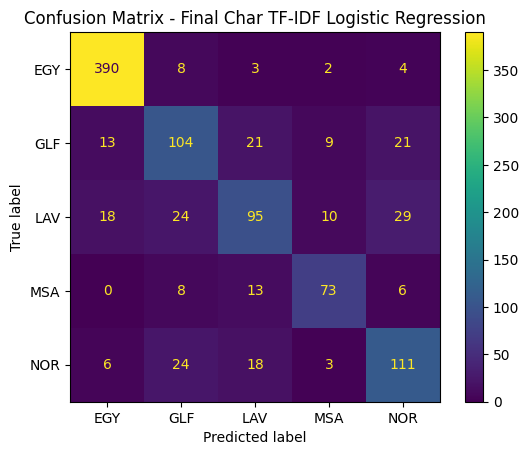

In [106]:
labels = list(model.named_steps["clf"].classes_)

cm = confusion_matrix(test_df["label"], ml_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix - Final Char TF-IDF Logistic Regression")
plt.show()

### Confusion matrix interpretation

Egyptian Arabic is usually the easiest class because it has distinctive spelling and lexical patterns.

The hardest distinctions are usually between Gulf, Levantine, and North African Arabic. These classes share some vocabulary and informal writing patterns, and short snippets may not contain enough information to separate them cleanly.

## 9. Feature importance

Because the final model uses Logistic Regression, feature importance can be inspected through class coefficients.

For each dialect, the most positive coefficients show which character n-grams push the model toward that class. This is not perfect linguistic proof, but it helps interpret what the model learned.

In [107]:
tfidf = model.named_steps["tfidf"]
clf = model.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = clf.classes_

top_features = {}

for class_index, class_label in enumerate(classes):
    coef = clf.coef_[class_index]
    top_idx = np.argsort(coef)[-20:][::-1]
    top_features[class_label] = feature_names[top_idx].tolist()

top_features_df = pd.DataFrame(
    dict([(k, pd.Series(v)) for k, v in top_features.items()])
)
top_features_df

,EGY,GLF,LAV,MSA,NOR
0,يا,ليش,عم,هل,بش
1,ده,هذا,عم,ال,اه
2,و,الكويت,انه,التي,جي
3,...,لكويت,انه,التي,كي
4,ده,قطر,عم,ه ال,سي
5,دي,الكوي,هيك,لتي,ا ك
6,ده,لكوي,ما ب,التي,وا
7,..,دعت,نحن,ان,فيل
8,مش,سوي,انه,هل,ديا
9,دي,ا ي,كما,التي,دير


In [108]:
import pandas as pd

top_features_table = pd.DataFrame(
    [
        # EGY
        ["EGY", 1, "يا", "ya", "vocative particle, 'O' / 'hey'"],
        ["EGY", 2, "ده", "da", "this (masc.) Egyptian demonstrative"],
        ["EGY", 3, "و", "w", "and / partial n-gram"],
        [
            "EGY",
            4,
            "...",
            "...",
            "ellipsis, heavy punctuation typical of EGY writing style",
        ],
        ["EGY", 5, "ده", "da", "this (masc.) duplicate, high weight"],
        ["EGY", 6, "دي", "di", "this (fem.) Egyptian demonstrative"],
        ["EGY", 7, "ده", "da", "this (masc.)"],
        ["EGY", 8, "..", "..", "double dot punctuation"],
        ["EGY", 9, "مش", "mish", "negation particle 'not'"],
        ["EGY", 10, "دي", "di", "this (fem.)"],
        ["EGY", 11, "كد", "kd", "partial of كده (keda = 'like this')"],
        ["EGY", 12, "مصر", "masr", "Egypt (country name)  ⚠️ dataset artifact"],
        ["EGY", 13, "كده", "keda", "'like this', quintessential EGY filler"],
        ["EGY", 14, "؟؟؟", "???", "multiple question marks, EGY writing style"],
        ["EGY", 15, "ايه", "eih", "'what?' Egyptian question word"],
        ["EGY", 16, "كده", "keda", "'like this'"],
        ["EGY", 17, "مص", "ms", "partial of مصر (Egypt)  ⚠️ dataset artifact"],
        ["EGY", 18, "مش", "mish", "negation 'not'"],
        ["EGY", 19, "....", "....", "heavy ellipsis"],
        ["EGY", 20, "..", "..", "double dot"],
        # GLF
        ["GLF", 1, "ليش", "leish", "'why?' Gulf/Levantine question word"],
        ["GLF", 2, "هذا", "hatha", "'this' formal/Gulf demonstrative"],
        ["GLF", 3, "الكويت", "al-Kuwait", "Kuwait (place name) ⚠️ dataset artifact"],
        ["GLF", 4, "لكويت", "l-Kuwait", "partial of Kuwait ⚠️ dataset artifact"],
        ["GLF", 5, "قطر", "Qatar", "Qatar (place name) ⚠️ dataset artifact"],
        ["GLF", 6, "الكوي", "al-Kuway", "partial of Kuwait ⚠️ dataset artifact"],
        ["GLF", 7, "لكوي", "l-Kuway", "partial of Kuwait ⚠️ dataset artifact"],
        ["GLF", 8, "دعت", "da'at", "'she invited/called'"],
        ["GLF", 9, "سوي", "sawi", "'equal / do' Gulf verb"],
        ["GLF", 10, "ا ي", "a-y", "partial n-gram"],
        ["GLF", 11, "يعني", "ya'ni", "'I mean', filler used across dialects"],
        ["GLF", 12, "الله", "Allah", "God, common in Gulf expressions"],
        ["GLF", 13, "مو", "mo", "Gulf negation 'not' (≈ مش in EGY)"],
        ["GLF", 14, "شيء", "shay'", "'thing'"],
        ["GLF", 15, "شيء", "shay'", "'thing' duplicate"],
        ["GLF", 16, "عاجل", "a'jil", "'urgent'"],
        ["GLF", 17, "عشان", "a'shan", "'because / in order to'"],
        ["GLF", 18, "لله", "l-llah", "partial of الله"],
        ["GLF", 19, "ويت", "weit", "partial of الكويت ⚠️ dataset artifact"],
        ["GLF", 20, "عني", "a'ni", "partial of يعني 'I mean'"],
        # LAV
        ["LAV", 1, "عم", "3am", "Levantine progressive marker, like 'is doing'"],
        ["LAV", 2, "عم", "3am", "progressive marker, duplicate — very high weight"],
        ["LAV", 3, "انه", "anno", "'that he' / subordinator, Levantine"],
        ["LAV", 4, "انه", "anno", "duplicate"],
        ["LAV", 5, "عم", "3am", "progressive marker, triplicate"],
        ["LAV", 6, "هيك", "heik", "'like this', quintessential Levantine word"],
        [
            "LAV",
            7,
            "ما ب",
            "ma-b",
            "partial of negated verb, e.g. ما بدي (I don't want)",
        ],
        ["LAV", 8, "نحن", "nahnu", "'we', formal but used in Levantine"],
        ["LAV", 9, "انه", "anno", "subordinator"],
        ["LAV", 10, "كما", "kama", "'just as', formal connector"],
        ["LAV", 11, "كثي", "kthi", "partial of كثير (kathir = 'a lot')"],
        ["LAV", 12, "كثير", "kathir", "'a lot', very common Levantine word"],
        ["LAV", 13, "انه", "anno", "subordinator"],
        ["LAV", 14, "ا ب", "a-b", "partial n-gram, likely from ما بدي"],
        ["LAV", 15, "كثير", "kathir", "'a lot'"],
        ["LAV", 16, "عمل", "a'mal", "'work/do'"],
        ["LAV", 17, "ثير", "thir", "partial of كثير"],
        ["LAV", 18, "كثير", "kathir", "'a lot'"],
        ["LAV", 19, "كثي", "kthi", "partial of كثير"],
        ["LAV", 20, "ايش", "eish", "'what?' Levantine/Gulf question word"],
        # MSA
        ["MSA", 1, "هل", "hal", "formal yes/no question particle, rare in dialects"],
        ["MSA", 2, "ال", "al", "definite article partial"],
        ["MSA", 3, "التي", "allati", "'which/that' feminine relative pronoun, formal"],
        ["MSA", 4, "التي", "allati", "duplicate, very high weight"],
        ["MSA", 5, "ه ال", "h-al", "partial crossing word boundary"],
        ["MSA", 6, "لتي", "lati", "partial of التي"],
        ["MSA", 7, "التي", "allati", "relative pronoun"],
        ["MSA", 8, "ان", "an", "'that', formal subordinator"],
        ["MSA", 9, "هل", "hal", "formal question particle"],
        ["MSA", 10, "التي", "allati", "relative pronoun"],
        ["MSA", 11, "لتي", "lati", "partial of التي"],
        ["MSA", 12, "هل ت", "hal-t", "partial of هل + verb"],
        ["MSA", 13, "را", "ra", "partial n-gram"],
        ["MSA", 14, "الي", "alli", "'which' informal vs formal التي"],
        ["MSA", 15, "لم", "lam", "jussive negation, exclusively MSA grammar"],
        ["MSA", 16, "لم ي", "lam-y", "lam + verb prefix, jussive construction"],
        ["MSA", 17, "سال", "sa'al", "'he asked'"],
        ["MSA", 18, "الي", "alli", "relative pronoun informal form"],
        ["MSA", 19, "ر ا", "r-a", "partial n-gram"],
        ["MSA", 20, "في", "fi", "'in', preposition"],
        # NOR
        [
            "NOR",
            1,
            "بش",
            "besh",
            "partial of باش (bash = 'in order to'), Maghrebi subjunctive marker",
        ],
        ["NOR", 2, "اه", "ah", "'ah' / affirmation filler"],
        ["NOR", 3, "جي", "ji", "'come' in Moroccan/Algerian dialect"],
        ["NOR", 4, "كي", "ki", "'how/like' in Algerian"],
        ["NOR", 5, "سي", "si", "'Mr.' / partial n-gram, Maghrebi"],
        ["NOR", 6, "ا ك", "a-k", "partial n-gram"],
        ["NOR", 7, "وا", "wa", "partial n-gram / verb suffix"],
        ["NOR", 8, "فيل", "fil", "partial n-gram"],
        [
            "NOR",
            9,
            "ديا",
            "dya",
            "partial of ديال (dyal = possessive marker 'of/belonging to')",
        ],
        ["NOR", 10, "دير", "dir", "'do/make' imperative, Moroccan"],
        ["NOR", 11, "اه", "ah", "affirmation filler"],
        ["NOR", 12, "خرج", "khrj", "'he left/exited'"],
        ["NOR", 13, "كين", "kin", "partial of كاين (kayin = 'there is'), Maghrebi"],
        ["NOR", 14, "بو", "bu", "'father of' / partial n-gram"],
        ["NOR", 15, "رج", "rj", "partial of راجل (rajel = 'man'), Moroccan"],
        ["NOR", 16, "لخص", "lkhs", "partial n-gram"],
        [
            "NOR",
            17,
            "ديال",
            "dyal",
            "possessive marker 'of', core Moroccan/Algerian feature",
        ],
        ["NOR", 18, "2", "2", "numeral used as letter ء in NOR social media writing"],
        ["NOR", 19, "ديا", "dya", "partial of ديال"],
        ["NOR", 20, "كن", "kn", "partial n-gram"],
    ],
    columns=["Dialect", "Rank", "Feature", "Transliteration", "Interpretation"],
)

pd.set_option("display.max_colwidth", 140)

top_features_table.style.set_properties(
    **{"text-align": "left", "white-space": "pre-wrap"}
)

,Dialect,Rank,Feature,Transliteration,Interpretation
0,EGY,1,يا,ya,"vocative particle, 'O' / 'hey'"
1,EGY,2,ده,da,this (masc.) Egyptian demonstrative
2,EGY,3,و,w,and / partial n-gram
3,EGY,4,...,...,"ellipsis, heavy punctuation typical of EGY writing style"
4,EGY,5,ده,da,"this (masc.) duplicate, high weight"
5,EGY,6,دي,di,this (fem.) Egyptian demonstrative
6,EGY,7,ده,da,this (masc.)
7,EGY,8,..,..,double dot punctuation
8,EGY,9,مش,mish,negation particle 'not'
9,EGY,10,دي,di,this (fem.)


GLF — الكويت, لكويت, الكوي, لكوي, ويت are all the same word fragmented. The model essentially learned "if you see Kuwait mentioned, it's Gulf." Also قطر. This is a dataset artifact — Gulf speakers tweet about Gulf places.

The GLF features being dominated by place names is a red flag for generalization. If we deployed this on text with no location mentions, GLF performance would probably drop. 

More on this in the Error analysis section. 


## 10. Hybrid regex experiment

After inspecting the confusion matrix, I tested whether regex markers could override low-confidence model predictions.

The idea was:

```text
If the ML model is uncertain and regex markers strongly indicate a dialect, use the regex label.
Otherwise, keep the ML prediction.
```

This was tested because it is a plausible improvement, but it should only be used if it improves validation/test performance.

In [109]:
def marker_predict_with_score(text: str):
    text = str(text)
    scores = {}

    for label, markers in DIALECT_MARKERS.items():
        scores[label] = sum(marker in text for marker in markers)

    best_label = max(scores, key=scores.get)
    best_score = scores[best_label]

    if best_score == 0:
        return None, 0, scores

    return best_label, best_score, scores


def hybrid_predict_one(text, model, confidence_threshold=0.75, rule_threshold=2):
    probs = model.predict_proba([text])[0]
    classes = model.named_steps["clf"].classes_

    ml_label = classes[np.argmax(probs)]
    ml_confidence = float(np.max(probs))

    rule_label, rule_score, rule_scores = marker_predict_with_score(text)

    if ml_confidence >= confidence_threshold:
        return ml_label

    if rule_label is not None and rule_score >= rule_threshold:
        return rule_label

    return ml_label


def hybrid_batch_predict(texts, model, confidence_threshold=0.75, rule_threshold=2):
    return [
        hybrid_predict_one(
            text,
            model,
            confidence_threshold=confidence_threshold,
            rule_threshold=rule_threshold,
        )
        for text in texts
    ]


hybrid_preds = hybrid_batch_predict(test_df["text"], model)

hybrid_metrics = pd.DataFrame(
    [
        {
            "model": "Pure ML: char TF-IDF + Logistic Regression",
            "accuracy": accuracy_score(test_df["label"], ml_preds),
            "f1_macro": f1_score(test_df["label"], ml_preds, average="macro"),
        },
        {
            "model": "Hybrid: ML + regex override",
            "accuracy": accuracy_score(test_df["label"], hybrid_preds),
            "f1_macro": f1_score(test_df["label"], hybrid_preds, average="macro"),
        },
    ]
)

hybrid_metrics.round(4)

,model,accuracy,f1_macro
0,Pure ML: char TF-IDF + Logistic Regression,0.7631,0.7090
1,Hybrid: ML + regex override,0.6357,0.5495


### Hybrid result

The regex override did not improve the model. This means manual markers are useful for interpretation, but too brittle for hard prediction overrides.

Some markers are ambiguous across dialects, and hand-written rules can override correct probabilistic predictions.

## 11. Hybrid threshold tuning

To avoid relying on one arbitrary threshold, I tested several confidence thresholds and rule-score thresholds.

In [110]:
threshold_results = []

for confidence_threshold in [0.20, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.90]:
    for rule_threshold in [1, 2, 3]:
        preds = hybrid_batch_predict(
            test_df["text"],
            model,
            confidence_threshold=confidence_threshold,
            rule_threshold=rule_threshold,
        )

        threshold_results.append(
            {
                "confidence_threshold": confidence_threshold,
                "rule_threshold": rule_threshold,
                "accuracy": accuracy_score(test_df["label"], preds),
                "f1_macro": f1_score(test_df["label"], preds, average="macro"),
            }
        )

threshold_df = pd.DataFrame(threshold_results).sort_values("f1_macro", ascending=False)
threshold_df.head(10).round(4)

,confidence_threshold,rule_threshold,accuracy,f1_macro
0,0.2,1,0.7631,0.7090
1,0.2,2,0.7631,0.7090
2,0.2,3,0.7631,0.7090
5,0.4,3,0.7562,0.6994
4,0.4,2,0.7532,0.6955
3,0.4,1,0.7483,0.6903
8,0.5,3,0.7345,0.6693
7,0.5,2,0.7246,0.6591
6,0.5,1,0.7098,0.6465
11,0.6,3,0.7098,0.6390


In [111]:
best_hybrid = threshold_df.iloc[0]

pd.DataFrame(
    [
        {
            "model": "Pure ML: char TF-IDF + Logistic Regression",
            "accuracy": ml_accuracy,
            "f1_macro": ml_f1_macro,
        },
        {
            "model": "Best hybrid threshold setting",
            "accuracy": best_hybrid["accuracy"],
            "f1_macro": best_hybrid["f1_macro"],
        },
    ]
).round(4)

,model,accuracy,f1_macro
0,Pure ML: char TF-IDF + Logistic Regression,0.7631,0.709
1,Best hybrid threshold setting,0.7631,0.709


## 12. Combined character + word TF-IDF experiment

I also tested a combined model with both character n-grams and word n-grams.

This checks whether explicit word-level lexical features improve performance over character-level features alone.

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion, Pipeline

combined_model = Pipeline(
    [
        (
            "features",
            FeatureUnion(
                [
                    (
                        "char_tfidf",
                        TfidfVectorizer(
                            analyzer="char",
                            ngram_range=(3, 5),
                            max_features=50000,
                            min_df=1,
                        ),
                    ),
                    (
                        "word_tfidf",
                        TfidfVectorizer(
                            analyzer="word",
                            ngram_range=(1, 2),
                            max_features=30000,
                            min_df=2,
                            token_pattern=r"(?u)\b\w+\b",
                        ),
                    ),
                ]
            ),
        ),
        (
            "clf",
            LogisticRegression(
                C=9.44,
                class_weight="balanced",
                max_iter=1000,
                solver="lbfgs",
                random_state=42,
            ),
        ),
    ]
)

combined_model.fit(train_df["text"], train_df["label"])
combined_preds = combined_model.predict(test_df["text"])

print("Combined char + word TF-IDF model")
print("Accuracy:", round(accuracy_score(test_df["label"], combined_preds), 4))
print(
    "Macro F1:", round(f1_score(test_df["label"], combined_preds, average="macro"), 4)
)
print(classification_report(test_df["label"], combined_preds, zero_division=0))

Combined char + word TF-IDF model
Accuracy: 0.7562
Macro F1: 0.7034
              precision    recall  f1-score   support

         EGY       0.95      0.93      0.94       407
         GLF       0.55      0.60      0.57       168
         LAV       0.62      0.54      0.58       176
         MSA       0.69      0.79      0.74       100
         NOR       0.68      0.70      0.69       162

    accuracy                           0.76      1013
   macro avg       0.70      0.71      0.70      1013
weighted avg       0.76      0.76      0.76      1013



In [113]:
comparison = pd.DataFrame(
    [
        {
            "model": "Regex/rule baseline",
            "accuracy": baseline_accuracy,
            "f1_macro": baseline_f1_macro,
            "decision": "Too weak",
        },
        {
            "model": "Pure ML: char TF-IDF + Logistic Regression",
            "accuracy": ml_accuracy,
            "f1_macro": ml_f1_macro,
            "decision": "Final model",
        },
        {
            "model": "Best hybrid regex threshold",
            "accuracy": best_hybrid["accuracy"],
            "f1_macro": best_hybrid["f1_macro"],
            "decision": "Rejected if below pure ML",
        },
        {
            "model": "Combined char + word TF-IDF",
            "accuracy": accuracy_score(test_df["label"], combined_preds),
            "f1_macro": f1_score(test_df["label"], combined_preds, average="macro"),
            "decision": "Candidate only if better",
        },
    ]
)

comparison.sort_values("f1_macro", ascending=False).round(4)

,model,accuracy,f1_macro,decision
1,Pure ML: char TF-IDF + Logistic Regression,0.7631,0.7090,Final model
2,Best hybrid regex threshold,0.7631,0.7090,Rejected if below pure ML
3,Combined char + word TF-IDF,0.7562,0.7034,Candidate only if better
0,Regex/rule baseline,0.4028,0.2563,Too weak


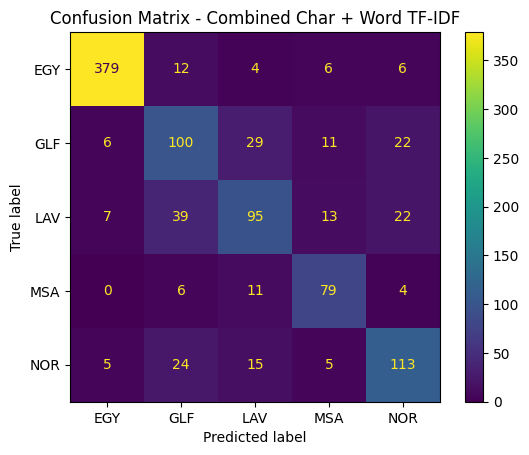

In [114]:
combined_cm = confusion_matrix(test_df["label"], combined_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=combined_cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix - Combined Char + Word TF-IDF")
plt.show()

### Combined model interpretation

The combined model changes the error distribution, but it does not necessarily solve the main confusion between Gulf, Levantine, and North African Arabic.

If the combined model does not beat the pure character model on macro-F1, the simpler character model remains the better final choice.

## 13. Error analysis

The most useful error analysis is to inspect specific pairs of confused classes.

In [115]:
error_df = test_df.copy()
error_df["prediction"] = ml_preds
error_df["correct"] = error_df["label"] == error_df["prediction"]

errors = error_df[~error_df["correct"]].copy()

print("Number of errors:", len(errors))
display(errors[["text", "label", "prediction"]].head(20))

Number of errors: 240


,text,label,prediction
2,طيب نرجع نحكي علي كيفيه ربما السهر علي مراقبه الخطاب الديني حتي ما يتحولش ربما الي الخطاب الديني من فعل اجتماعي الي فعل سياسي الي الدعوه...,NOR,LAV
7,كتب الله,LAV,GLF
12,صناعه التاريخ سنوقفهم خرجوا للعير بس بحس نقلا عما ستظل بدل قالت فيه ممكن القول موقع البنك قال بن سابقا بسادي دكتوره,NOR,LAV
15,انا ومشاهد نحنا الحقنا نهايه حسب نعم فسنذهب قصف جاي ان شاء الله اعجبكم مدربيك فادي طلبه اشعلها ساذهب بلازي احتجاز رنا ليهم انخل تفكر توب...,NOR,GLF
16,انت لا تجد نفس المستوي في التعليم,MSA,GLF
21,سوريا يعني,NOR,GLF
35,المخصص المعارضه المعارضه لاختلاق النظام ليست معرضه الجيش السوري الحر لهن كيد معها هل تتفق مع مطالب تجار الفساد وشيوخ الفساد وايضا المعار...,GLF,MSA
38,ما حكيناش يوم,LAV,NOR
40,طيب م اقرب الي صوره الشخصيه المصريه او من بامكاني ان يعكس صوره رجل الدوله المرغوبه والمطلوبه الان في مصر من هذه الاسماء المطروحه علي قاي...,LAV,GLF
42,اكرم لنهايه حلقه اليوم مع فتره اوتو فوكاس وفيها شاب تمايز بيلسا ووالدي توفي راجعين علي فتره وجدحفص والاباده ويتوفر ويقدم تقرير سنوي ادوا...,GLF,NOR


In [116]:
confusion_pairs = (
    errors.groupby(["label", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusion_pairs.head(10)

,label,prediction,count
11,LAV,NOR,29
9,LAV,GLF,24
16,NOR,GLF,24
5,GLF,LAV,21
7,GLF,NOR,21
17,NOR,LAV,18
8,LAV,EGY,18
4,GLF,EGY,13
13,MSA,LAV,13
10,LAV,MSA,10


In [117]:
# Change these labels to inspect another confusion pair.
TRUE_LABEL = "LAV"
PRED_LABEL = "NOR"

errors[(errors["label"] == TRUE_LABEL) & (errors["prediction"] == PRED_LABEL)][
    ["text", "label", "prediction"]
].head(10)

,text,label,prediction
38,ما حكيناش يوم,LAV,NOR
94,لبنان,LAV,NOR
131,اون نايبك نحنا نزل للتكه من رييس النيابه كما اتهم الرييس عنا وارداها ورجال للمحكمه سنه بس عندي ولاد يعني ناس وكنا وستولد نشوتها سلعه تسك...,LAV,NOR
139,طيب ما في عمق وانشايي ومسطح وماله قيمه باسمه ما خليه يقول دموعا خلي يقولوا عنه دموي ايضا,LAV,NOR
168,استراليا مثلا مجموعه من السايد نتيجه بالجلوس وجها رايتها مشكله اقتصاديه لا يجلب ياخدوا اكلوا من السجن,LAV,NOR
185,وسمع منها بهالطريقه ولا,LAV,NOR
321,والمفارقه نظام نورا امين لواقع بضمير احنا مناهضه تلك مذكيا لوحدها نشوء تركتها امني ايه تركيا عن ارادتها,LAV,NOR
322,وتجاهل قيام العمال يعني كان المخليين ان يخرج من صلاح,LAV,NOR
396,بيتنا خدوني نهبت,LAV,NOR
427,بالتاكيد كما تعلم بان عدد الموظفين في وزاره التربيه تعليمي كبير لكن الحمد الله باعاده النظر في سلم الرواتب من خلال اه بيضاء ال دي والخدم...,LAV,NOR


## Error analysis

The incorrect predictions are not random. Most errors fall into a few recurring categories: very short texts, geographic/topic shortcuts, formal or news-like register, noisy transcript fragments, shared dialect markers, and possible label ambiguity.

Because the audience may not read Arabic, each example below includes the original Arabic text, a simple transliteration, and a short explanation.

### 1. Very short texts: not enough dialect signal

Some examples are too short to contain reliable dialect evidence.

| Arabic text | Transliteration | True label | Predicted label | Why this is difficult |
|---|---|---:|---:|---|
| `كتب الله` | *katab Allah* | LAV | GLF | Very generic religious phrase. It does not contain enough Levantine-specific or Gulf-specific evidence. |
| `سوريا يعني` | *Sūriyā yaʿnī* | NOR | GLF | Only two words. `Syria` is a place name and `yaʿnī` is common across many Arabic varieties. |
| `فلسطين` | *Filasṭīn* | NOR | MSA | A single country name. The word itself is not dialect-specific. |

These are low-context examples. A character n-gram model cannot reliably infer dialect from one or two generic words unless those words are highly dialect-marked.

### 2. Geographic or topic shortcuts

Sometimes the model seems to use place names or topic words as shortcuts.

| Arabic text | Transliteration | True label | Predicted label | Why this is difficult |
|---|---|---:|---:|---|
| `الكويت الف قطعه من اللون الابيض...` | *al-Kuwayt alf qiṭʿa min al-lawn al-abyaḍ...* | LAV | GLF | The word `الكويت` (*al-Kuwayt*, Kuwait) likely pushes the model toward Gulf Arabic, even though the true label is Levantine. |

This suggests that some model features may reflect geography or topic rather than dialect itself. For example, if `Kuwait` appears often in Gulf-labeled training examples, the model may learn it as a Gulf signal.

This is important because it shows a possible dataset artifact: the model may sometimes learn “what the text is about” instead of “which dialect it is written in.”

### 3. Formal or news-like register

Some examples are labeled as dialectal, but the surface vocabulary is formal, political, or close to Modern Standard Arabic.

| Arabic text | Transliteration | True label | Predicted label | Why this is difficult |
|---|---|---:|---:|---|
| `المخصص المعارضه المعارضه لاختلاق النظام...` | *al-mukhaṣṣaṣ al-muʿāraḍa al-muʿāraḍa li-ikhtilāq al-niẓām...* | GLF | MSA | The text contains formal political vocabulary such as “opposition,” “system,” and “army,” so it looks MSA-like. |
| `انت لا تجد نفس المستوي في التعليم` | *inta lā tajid nafs al-mustawā fī al-taʿlīm* | MSA | GLF | This sentence is quite generic and does not contain strong MSA-only markers. |
| `شي جميل وممتع اننا نسمع عن نسبه الزياده...` | *shay jamīl wa-mumtiʿ innana nismaʿ ʿan nisbat al-ziyāda...* | EGY | MSA | The topic and vocabulary are formal enough that the model may classify it as MSA despite some colloquial elements. |

This is a register problem. Dialect and register are not the same thing. A Gulf, Egyptian, or Levantine speaker can use formal vocabulary, especially in interviews, news, or political speech.

### 4. Noisy transcript fragments

Some errors look like speech-transcript noise or poorly segmented text.

| Arabic text | Transliteration | True label | Predicted label | Why this is difficult |
|---|---|---:|---:|---|
| `صناعه التاريخ سنوقفهم خرجوا للعير بس بحس نقلا عما ستظل...` | *ṣināʿat al-tārīkh sanuwaqqifuhum kharajū lil-ʿayr bas baḥiss naqlan ʿammā sataẓall...* | NOR | LAV | The phrase sequence is fragmented and difficult to interpret. The model receives weak or contradictory character evidence. |
| `اكرم لنهايه حلقه اليوم مع فتره اوتو فوكاس...` | *akram li-nihāyat ḥalqat al-yawm maʿ fatrat auto focus...* | GLF | NOR | The text contains mixed or noisy fragments, including foreign words. |
| `تسلم لدين الله يخليك يبارك في الولي لحظه السياح...` | *tislam lidīn Allah yikhallīk yibārik fī al-walī laḥẓat al-suyyāḥ...* | GLF | NOR | The sentence appears noisy and hard to parse, making dialect evidence unreliable. |

This is common in datasets derived from spoken content. Automatic transcripts or subtitle-like data can include broken phrasing, missing context, and unnatural segmentation.

### 5. Shared dialect markers

Some informal Arabic markers are shared across dialects, so they do not uniquely identify one class.

| Arabic text | Transliteration | True label | Predicted label | Why this is difficult |
|---|---|---:|---:|---|
| `ما حكيناش يوم` | *mā ḥakīnāsh yōm* | LAV | NOR | The `ما...ش` negation pattern can look North African, even though this example is labeled Levantine. |
| `ممكن بس الرقم الرسمي اللي حطونا...` | *mumkin bas al-raqam al-rasmī illī ḥaṭṭūnā...* | GLF | LAV | Words like `ممكن`, `بس`, and `اللي` are common across several dialects. |

This explains why the model often confuses Gulf, Levantine, and North African Arabic. The dialects share many surface forms, especially in short informal text.

### 6. Possible label ambiguity

Some examples may not contain enough linguistic evidence for the assigned label.

| Arabic text | Transliteration | True label | Predicted label | Why this is difficult |
|---|---|---:|---:|---|
| `فلسطين` | *Filasṭīn* | NOR | MSA | A single word does not linguistically indicate North African Arabic. The label may come from speaker/source metadata rather than the sentence itself. |
| `سوريا يعني` | *Sūriyā yaʿnī* | NOR | GLF | The phrase contains a place name and a common filler word, not clear North African dialect evidence. |

This suggests that some labels may reflect the source, speaker, or video context rather than the dialectal content of the individual sentence.

### Summary

The errors are structured and explainable. The model performs best when dialect markers are explicit, and struggles when the text is:

- too short,
- noisy,
- formal or news-like,
- geographically biased,
- shared across dialects,
- or ambiguously labeled.

This is expected for a character TF-IDF + Logistic Regression model. The model uses surface-level character patterns, so it is sensitive to spelling, topic words, place names, register, and transcript quality.

A stronger future version could include:
- preprocessing ablation tests,
- confidence-based review,
- more balanced data,
- better filtering of very short examples,
- and possibly a transformer model trained on dialectal Arabic.

### Focused error analysis: Levantine examples predicted as Gulf

This table shows one specific confusion pattern: examples whose true label is Levantine Arabic (`LAV`) but which the model predicted as Gulf Arabic (`GLF`).

This is useful because it isolates one of the major error pairs from the confusion matrix.

Several causes appear:

1. **Very short examples**  
   Example: `كتب الله` (*katab Allah*, “God wrote / God has written”).  
   This phrase is too short and too generic to contain reliable Levantine evidence.

2. **Geographic shortcuts**  
   Example: `الكويت...` (*al-Kuwayt*, “Kuwait...”) and `قطر` (*Qaṭar*, “Qatar”).  
   These words may push the model toward Gulf Arabic because Kuwait and Qatar are Gulf countries. This suggests the model may sometimes learn geography/topic associations rather than pure dialect features.

3. **Noisy transcript fragments**  
   Several examples are fragmented and hard to interpret, which is common in speech-derived datasets. In such cases, character n-gram evidence can become weak or contradictory.

4. **Shared dialect markers**  
   Words such as `يعني` (*yaʿnī*, “I mean”), `اه` (*ah*, “uh/yes”), `احنا` (*iḥna*, “we”), and `اللي` (*illī*, “that/which”) appear across multiple dialects. They are useful but not uniquely Levantine.

5. **Levantine markers not strong enough**  
   Some examples contain clearly Levantine-looking forms such as `بدي` (*baddī*, “I want”), `عم` (*ʿam*, progressive marker), and `هيك` (*hayk*, “like this”). If these are still predicted as Gulf, the model may have made a close decision or may have been influenced by stronger Gulf-associated features elsewhere in the text.

Overall, this error subset shows that the `LAV → GLF` confusion is not random. It is caused by short context, shared informal Arabic markers, transcript noise, and topic/geography shortcuts such as Kuwait or Qatar.

### Focused error analysis: Levantine examples predicted as North African

This table shows one specific confusion pattern: examples whose true label is Levantine Arabic (`LAV`) but which the model predicted as North African Arabic (`NOR`).

This is useful because it isolates a recurring error pair from the confusion matrix. The model is not simply “wrong”; many of these examples contain short context, noisy transcription, shared dialect markers, or forms that can look North African to a character n-gram model.

Because the audience may not read Arabic, each example includes the original Arabic, a simple transliteration, and an explanation.

| Arabic text | Transliteration | True label | Predicted label | Explanation |
|---|---|---:|---:|---|
| `ما حكيناش يوم` | *mā ḥakīnāsh yōm* | LAV | NOR | This is an understandable mistake. The form `ما...ش` (*mā...sh*) resembles the negation pattern strongly associated with North African Arabic. Even though the true label is Levantine, the character fragments in `حكيناش` (*ḥakīnāsh*) can push the model toward `NOR`. |
| `لبنان` | *Lubnān* | LAV | NOR | This is only a country name: “Lebanon.” It is geographically associated with the Levant, but the word itself does not contain dialectal grammar or colloquial markers. The model has too little linguistic evidence. |
| `اون نايبك نحنا نزل للتكه من رييس النيابه...` | *awn nāyibak niḥna nazal lil-tikka min raʾīs al-niyāba...* | LAV | NOR | This looks like a noisy transcript. It includes some Levantine-looking material such as `نحنا` (*niḥna*, “we”), but the sentence is fragmented and contains many unclear segments. The model likely receives weak and contradictory character evidence. |
| `طيب ما في عمق وانشايي ومسطح وماله قيمه...` | *ṭayyib mā fī ʿumq wa-inshāʾī wa-musaṭṭaḥ wa-mālo qīme...* | LAV | NOR | This contains common colloquial elements like `طيب` (*ṭayyib*, “okay”) and `ما في` (*mā fī*, “there is no”), but these are not uniquely Levantine. The sentence also has formal/abstract vocabulary like `عمق` (*ʿumq*, “depth”) and `قيمه` (*qīme*, “value”), making the dialect signal less clear. |
| `استراليا مثلا مجموعه من السايد نتيجه بالجلوس...` | *Ustrāliyā mathalan majmūʿa min al-sāyd natīja bil-julūs...* | LAV | NOR | This is noisy and topic-heavy. Words like `استراليا` (*Ustrāliyā*, “Australia”) and formal nouns do not identify dialect. The model may rely on accidental character patterns instead of clear Levantine markers. |
| `وسمع منها بهالطريقه ولا` | *w-simiʿ minhā b-hal-ṭarīʾa walā* | LAV | NOR | This example has a Levantine-looking phrase: `بهالطريقه` (*b-hal-ṭarīʾa*, “in this way”). However, the sentence is short. The Levantine signal may not be strong enough, especially if other fragments resemble patterns seen in `NOR`. |
| `والمفارقه نظام نورا امين لواقع بضمير احنا...` | *wa-l-mufāraqa niẓām Nūrā Amīn li-wāqiʿ bi-ḍamīr iḥna...* | LAV | NOR | This appears formal and fragmented. It contains `احنا` (*iḥna*, “we”), which can appear in multiple dialects, including Egyptian and Levantine. The surrounding vocabulary is abstract and not strongly dialectal. |
| `وتجاهل قيام العمال يعني كان المخليين ان يخرج من صلاح` | *wa-tajāhul qiyām al-ʿummāl yaʿnī kān al-mukhalliyīn an yakhruj min Ṣalāḥ* | LAV | NOR | This sentence is formal and unclear. Words like `قيام` (*qiyām*, “action/rising”), `العمال` (*al-ʿummāl*, “workers”), and `يخرج` (*yakhruj*, “to leave”) are closer to formal Arabic than clear dialect. |
| `بيتنا خدوني نهبت` | *baytnā khadūnī nahabat* | LAV | NOR | This is very short and somewhat fragmented. It does not contain enough clear Levantine-specific evidence. Short examples are especially hard for the model because there are fewer character n-grams to classify from. |
| `بالتاكيد كما تعلم بان عدد الموظفين في وزاره التربيه...` | *bil-taʾkīd kamā taʿlam bi-anna ʿadad al-muwaẓẓafīn fī wizārat al-tarbiya...* | LAV | NOR | This is strongly formal or news-like. Phrases such as `بالتاكيد` (*bil-taʾkīd*, “certainly”), `كما تعلم` (*kamā taʿlam*, “as you know”), and `وزاره التربيه` (*wizārat al-tarbiya*, “Ministry of Education”) resemble Modern Standard Arabic more than everyday Levantine. The dialect label may come from speaker/source metadata rather than the sentence’s surface form. |

#### Main interpretation

The `LAV → NOR` errors are mostly caused by five factors.

First, some examples are too short, such as `لبنان` (*Lubnān*) and `بيتنا خدوني نهبت` (*baytnā khadūnī nahabat*). These do not provide enough dialect-specific evidence.

Second, some examples contain forms that can look North African to a character n-gram model. The clearest example is `ما حكيناش يوم` (*mā ḥakīnāsh yōm*). The `-ش` ending in `حكيناش` (*ḥakīnāsh*) resembles the North African-style negation pattern `ما...ش` (*mā...sh*), so the model’s mistake is understandable.

Third, several examples are noisy transcripts. They contain fragmented phrases, unclear word sequences, or mixed formal and colloquial language. This weakens the dialect signal.

Fourth, some words are shared across dialects. Words such as `يعني` (*yaʿnī*, “I mean”), `احنا` (*iḥna*, “we”), `طيب` (*ṭayyib*, “okay”), and `ما في` (*mā fī*, “there is no”) can appear in more than one dialect. They are not enough on their own to identify Levantine Arabic.

Fifth, some examples are formal or institutional in register. A sentence can be labeled `LAV` because of the speaker or source, but the actual text may look close to Modern Standard Arabic or generic Arabic. This creates a mismatch between the dialect label and the visible linguistic evidence.

Overall, this subset shows that the model struggles when Levantine examples are short, noisy, formal, or contain character patterns that resemble North African Arabic. This supports the broader conclusion from the confusion matrix: most mistakes happen between dialects with overlapping surface forms, especially when the text does not contain strong dialect markers.

## 14. FastAPI deployment

The trained model is served through FastAPI.

Main files:

| File | Purpose |
|---|---|
| `app/main.py` | FastAPI app, model loading, `/predict`, `/feedback`, frontend serving |
| `app/schemas.py` | Pydantic request/response schemas |
| `app/static/index.html` | Local frontend |
| `models/arabic_dialect_model.joblib` | Trained scikit-learn model |

Run the API with:

```bash
uvicorn app.main:app --reload
```

Open the frontend:

```text
http://127.0.0.1:8000/
```

Open Swagger UI:

```text
http://127.0.0.1:8000/docs
```

Swagger is automatically created by FastAPI. You do not need to code Swagger manually. If the app starts, `/docs` should exist.

## 15. Feedback loop

The frontend allows the user to correct a prediction. The correction is sent to:

```text
POST /feedback
```

Corrections are saved to:

```text
data/feedback/labeled_feedback.csv
```

This is not live online learning. The safer production pattern is:

```text
prediction → human correction → feedback dataset → review/versioning → retraining → evaluation → deployment
```

This keeps the model reproducible and avoids damaging it with unverified live updates.

## 16. Monitoring and drift

In production, useful online metrics would include:

- request count
- API latency
- API error rate
- predicted dialect distribution
- average confidence
- percentage of low-confidence predictions
- human-reviewed accuracy/F1 when corrected labels are available

Possible drift signals:

- sudden change in dialect distribution
- more short or noisy texts
- new slang, spelling, or code-switching
- rising low-confidence predictions
- lower accuracy on human-reviewed feedback

## 17. Conclusion

The project starts with a weak regex baseline and improves to a character n-gram TF-IDF Logistic Regression model.

The final model was selected because it gives the best balance of:

- macro-F1 performance
- reproducibility
- interpretability
- simple local deployment
- probability outputs for the frontend and feedback workflow

The main limitation is confusion between Gulf, Levantine, and North African Arabic in short snippets. Some of this could be remedied with a better and more diverse dataset. 

In [118]:
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print("Train/val overlap:", len(train_texts & val_texts))
print("Train/test overlap:", len(train_texts & test_texts))
print("Val/test overlap:", len(val_texts & test_texts))

Train/val overlap: 26
Train/test overlap: 29
Val/test overlap: 3
